## 데이터 탐색

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mlp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import plotly.graph_objects as go

sys.path.insert(0, r"C:\Users\signlab_039\Desktop\projects\bonglim\backend")

from sklearn.linear_model import ElasticNet
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from src.utils.funcs import plotting_hist_subplots, adjust_r2_score
from src.utils.data_preprocessing import remove_outlier_with_iqr, log_transformation

warnings.filterwarnings("ignore")
mlp.rcParams["font.family"] = "Malgun Gothic"
mlp.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv("../bonglim_steel.csv", encoding="utf8")
df

,보링회전 RPM-왼팔,보링회전 부하율-왼팔,핀 회전 RPM-왼팔,핀 회전 부하율-왼팔,"보링 가공 전,후 위치-왼팔","보링 가공 전,후 속도-왼팔","보링 가공 전,후 부하율-왼팔","드릴 상,하 위치-왼팔","드릴 상,하 속도-왼팔","드릴 상,하 부하율-왼팔",...,핀 회전 부하율-오른팔,"보링 가공 전,후 위치-오른팔","보링 가공 전,후 속도-오른팔","보링 가공 전,후 부하율-오른팔","드릴 상,하 위치-오른팔","드릴 상,하 속도-오른팔","드릴 상,하 부하율-오른팔",카운트-오른팔,싸이클타임-오른팔,등록일
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2025-01-21 13:51:07
1,0,108,0,90000,78,0,33,170000,0,25,...,65,90000,0,174,170000,0,0,3860,406,2025-02-13 14:28:21
2,0,109,0,90000,78,0,33,170000,0,25,...,65,90000,0,174,170000,0,43,3860,406,2025-02-13 14:28:22
3,0,109,0,90000,78,0,33,170000,0,25,...,65,90000,0,174,170000,0,43,3860,406,2025-02-13 14:28:28
4,0,109,-1,90000,78,0,33,170000,0,25,...,65,90000,0,174,170000,0,43,3860,406,2025-02-13 14:28:30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,1,117,1,90000,97,0,108,170000,0,31,...,80,90000,0,86,170000,0,0,3867,399,2025-02-13 15:54:38
1877,0,117,-1,90000,97,0,108,170000,0,31,...,80,90000,0,86,170000,0,0,3867,399,2025-02-13 15:54:39
1878,-1,117,0,90000,97,0,108,170000,0,31,...,80,90000,0,86,170000,0,43,3867,399,2025-02-13 15:54:40
1879,0,117,0,90000,97,0,108,170000,0,0,...,80,90000,0,86,170000,0,43,3867,399,2025-02-13 15:54:46


왼팔과 오른팔 각각 수집되는 데이터.

두 데이터를 한 번에 처리할 지 각각 처리할지 여부를 결정하기 위해 왼팔 오른팔 데이터를 분리하여 각각 요약 통계량을 확인해보자.

In [3]:
left_data = pd.concat([df[[col for col in df.columns if "왼팔" in col]], df['등록일']], axis=1)
right_data = pd.concat([df[[col for col in df.columns if "오른팔" in col]], df['등록일']], axis=1)

left_data.columns = [col.replace("-왼팔", "") for col in left_data.columns if col != "등록일"] + ['등록일']
right_data.columns = [col.replace("-오른팔", "") for col in right_data.columns if col != "등록일"] + ['등록일']

In [4]:
left_data.describe().T.style.background_gradient()

,count,mean,std,min,25%,50%,75%,max
보링회전 RPM,1881.000000,1001.246146,2996.079949,-2.000000,0.000000,0.000000,0.000000,10065.000000
보링회전 부하율,1881.000000,127.034024,25.550282,0.000000,114.000000,117.000000,142.000000,203.000000
핀 회전 RPM,1881.000000,1093.727804,3326.913246,-1.000000,0.000000,0.000000,0.000000,13514.000000
핀 회전 부하율,1881.000000,106069.766614,50634.018141,0.000000,90000.000000,90000.000000,90000.000000,300800.000000
"보링 가공 전,후 위치",1881.000000,111.212121,38.574026,0.000000,81.000000,107.000000,133.000000,242.000000
"보링 가공 전,후 속도",1881.000000,-16.623073,7189.033258,-92998.000000,0.000000,0.000000,0.000000,51635.000000
"보링 가공 전,후 부하율",1881.000000,91.484317,48.522838,0.000000,41.000000,101.000000,108.000000,255.000000
"드릴 상,하 위치",1881.000000,179953.203615,32741.957918,0.000000,170000.000000,170000.000000,170000.000000,304000.000000
"드릴 상,하 속도",1881.000000,-1.787879,8237.575938,-93101.000000,0.000000,0.000000,0.000000,51673.000000
"드릴 상,하 부하율",1881.000000,47.014886,57.175977,0.000000,26.000000,29.000000,31.000000,237.000000


In [5]:
right_data.describe().T.style.background_gradient()

,count,mean,std,min,25%,50%,75%,max
보링회전 PRM,1881.000000,948.675704,3003.476899,-1.000000,0.000000,0.000000,0.000000,10876.000000
보링회전 부하율,1881.000000,89.858586,33.103259,0.000000,78.000000,86.000000,104.000000,227.000000
핀 회전 PRM,1881.000000,986.424242,3166.257513,-1.000000,0.000000,0.000000,0.000000,13956.000000
핀 회전 부하율,1881.000000,89.342371,36.547037,0.000000,65.000000,85.000000,102.000000,246.000000
"보링 가공 전,후 위치",1881.000000,105073.858054,49912.998798,0.000000,90000.000000,90000.000000,90000.000000,305195.000000
"보링 가공 전,후 속도",1881.000000,-8.132908,6766.152058,-90015.000000,0.000000,0.000000,0.000000,51662.000000
"보링 가공 전,후 부하율",1881.000000,116.444444,50.954644,0.000000,86.000000,89.000000,174.000000,255.000000
"드릴 상,하 위치",1881.000000,177538.054226,28887.356825,0.000000,170000.000000,170000.000000,170000.000000,301000.000000
"드릴 상,하 속도",1881.000000,23.537480,7114.232724,-92952.000000,0.000000,0.000000,0.000000,51673.000000
"드릴 상,하 부하율",1881.000000,51.844763,43.018407,0.000000,40.000000,41.000000,43.000000,217.000000


오른팔과 왼팔의 경우 적지 않게 차이가 나는 모습을 보인다. 

왼팔과 오른팔을 분리하여 데이터를 분석하자.

### 왼팔 데이터부터 분석 시작

왼팔 데이터를 우선 살펴보자. 현재 예측해야 하는 대상은 `["보링 가공 전,후 속도"]`이다. 해당 컬럼과 더불어 드릴 상,하 속도에 현재 `-90,000`이라는 값이 찍히고 있다. 지우자.

In [6]:
new_data_index = left_data[left_data['보링 가공 전,후 속도'] < -100].index
left_data = left_data.loc[[idx for idx in left_data.index if idx not in new_data_index]].reset_index(drop=True)

In [7]:
left_data.head()

,보링회전 RPM,보링회전 부하율,핀 회전 RPM,핀 회전 부하율,"보링 가공 전,후 위치","보링 가공 전,후 속도","보링 가공 전,후 부하율","드릴 상,하 위치","드릴 상,하 속도","드릴 상,하 부하율",카운트,싸이클타임,등록일
0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01-21 13:51:07
1,0,108,0,90000,78,0,33,170000,0,25,3850,423,2025-02-13 14:28:21
2,0,109,0,90000,78,0,33,170000,0,25,3850,423,2025-02-13 14:28:22
3,0,109,0,90000,78,0,33,170000,0,25,3850,423,2025-02-13 14:28:28
4,0,109,-1,90000,78,0,33,170000,0,25,3850,423,2025-02-13 14:28:30


첫 5개 행의 target값이 모두 0이다. 타겟값만을 한번 살펴보자.

In [8]:
print(f"target column에 포함된 0값 개수 : {len([val for val in left_data['보링 가공 전,후 속도'].values if val==0])}개")
print(f"데이터의 전체 건수 : {left_data.shape[0]}")
left_data['보링 가공 전,후 속도'].unique()

target column에 포함된 0값 개수 : 1650개
데이터의 전체 건수 : 1871


array([    0,     3, 49968, 49999,  1781,  1880,  2090,  1762,  1716,
        1663,  1747,  1853,  1892,  1792,  1777,  1758,  1808,  1827,
        1796,  1392,  1472,  1319,  1174,  1056,  1228,    -3, 49972,
        3646,  1930,  1865,  1770,  2002,  1689,  1735,  1945,  1850,
        1888,  1834,  1789,  1831,  1857,  1411,  1464,  1380,  1045,
        1033,  1209, 50014,  1861,  1823,  1678,  1670,  1644,  1911,
        1731,  1873,  1636,  1499,  1800,  1712,  1399,   839,  1178,
       50022,  1934,  1785,  1903,  1876,  1815,  2052,  1754,  1548,
        1419,   915,  1117,  1220, 50010,  2048,  1926,  1983,  1842,
        1579, 51635,  1804,  1682,  1750,  1976,  1739,  1838,  1773,
        1846,  1819,  1724,  1708,  1480,  1449,  1090,   930,   892,
        1018, 47660, 49995,  1728,  1766,  1396,  1487,   900,   980,
        1029,   -15], dtype=int64)

### ※ Target Column에서 발생한 문제점
현재 1,881건의 데이터 중에서 1,650개의 target값이 0값이다. 

우리가 현재 해결해야 하는 문제의 경우 회귀 문제로, 회귀 모델 학습 시에는 타겟 값이 0이 아닌 데이터만 사용하는 것이 일반적이다. 타겟값에 무수히 많은 0이 포함되어 있다면, 실제로 의미있는 연속형 값을 학습하지 못해, 0을 과도하게 예측하는 문제가 발생할 수 있다.

따라서 다음과 같은 절차를 따라 결과를 도출해보자.

### classification 모델을 거친 뒤, 해당 컬럼의 target값이 0이 아닐 확률이 높은 경우에만 회귀모델로 실측값 예측
모델이 학습된 뒤 실제로 사용한다고 가정했을 때, 사용자들은 원하는 값을 1개 행으로 던질 것이다.

그렇다면 학습해둔 분류모델(특정 행의 target값이 0일지 아닐지를 분류하는 모델)을 거쳐서 target값이 0이 아닐때만 회귀모델을 활용하여 실제 "보링 가공 전,후 속도"를 정확한 수치로 예측해내는 회귀 모델로 속도를 예측하도록 Two-Stage 체제로 process를 가져가보자.

### 분류모델부터 학습
분류모델을 학습하기 위해서 label값을 부여해보자.

In [9]:
label = []
for val in left_data['보링 가공 전,후 속도'].values:
    if val == 0:
        label.append(0)
    else:
        label.append(1)
        
left_data['라벨값'] = label

In [10]:
left_data

,보링회전 RPM,보링회전 부하율,핀 회전 RPM,핀 회전 부하율,"보링 가공 전,후 위치","보링 가공 전,후 속도","보링 가공 전,후 부하율","드릴 상,하 위치","드릴 상,하 속도","드릴 상,하 부하율",카운트,싸이클타임,등록일,라벨값
0,0,0,0,0,0,0,0,0,0,0,0,0,2025-01-21 13:51:07,0
1,0,108,0,90000,78,0,33,170000,0,25,3850,423,2025-02-13 14:28:21,0
2,0,109,0,90000,78,0,33,170000,0,25,3850,423,2025-02-13 14:28:22,0
3,0,109,0,90000,78,0,33,170000,0,25,3850,423,2025-02-13 14:28:28,0
4,0,109,-1,90000,78,0,33,170000,0,25,3850,423,2025-02-13 14:28:30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866,1,117,1,90000,97,0,108,170000,0,31,3858,422,2025-02-13 15:54:38,0
1867,0,117,-1,90000,97,0,108,170000,0,31,3858,422,2025-02-13 15:54:39,0
1868,-1,117,0,90000,97,0,108,170000,0,31,3858,422,2025-02-13 15:54:40,0
1869,0,117,0,90000,97,0,108,170000,0,0,3858,422,2025-02-13 15:54:46,0


### 데이터 분할 후 데이터 정규화, 모델 학습

In [11]:
X_train, X_test, y_train, y_test = train_test_split(left_data.drop(["등록일", "라벨값"], axis=1), left_data['라벨값'], test_size=0.2, random_state=2025)

In [12]:
clf_scaler = MinMaxScaler(feature_range=(0.1, 1))
scaled_X_train = clf_scaler.fit_transform(X_train)
scaled_X_test = clf_scaler.transform(X_test)

In [14]:
import pickle

with open("../models/control/clf/scaler/clf_scaler.pkl", "wb") as classifier_scaler:
    pickle.dump(clf_scaler, classifier_scaler)

In [15]:
clf = LogisticRegression(random_state=2025, max_iter=10000)
clf.fit(scaled_X_train, y_train)

LogisticRegression(max_iter=10000, random_state=2025)

In [16]:
y_true = y_test
y_pred = clf.predict(scaled_X_test)

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       344
           1       0.96      0.87      0.92        31

    accuracy                           0.99       375
   macro avg       0.98      0.93      0.95       375
weighted avg       0.99      0.99      0.99       375



In [17]:
from joblib import dump

dump(clf, "../models/control/clf/model/clf_model.V1.0.joblib")

['../models/control/clf/model/clf_model.V1.0.joblib']

### 회귀 분석 진행

target값이 0이 아닌값들을 들고와서 회귀 분석을 진행하자

In [18]:
non_zero_data = left_data.loc[left_data[left_data['보링 가공 전,후 속도'] != 0].index].reset_index(drop=True)
non_zero_data

,보링회전 RPM,보링회전 부하율,핀 회전 RPM,핀 회전 부하율,"보링 가공 전,후 위치","보링 가공 전,후 속도","보링 가공 전,후 부하율","드릴 상,하 위치","드릴 상,하 속도","드릴 상,하 부하율",카운트,싸이클타임,등록일,라벨값
0,1,119,0,90000,71,3,33,170000,15,0,3850,423,2025-02-13 14:49:34,1
1,9971,149,9977,102444,114,49968,60,170000,0,25,3850,423,2025-02-13 14:49:36,1
2,10004,152,10004,197187,119,49999,77,187033,49964,0,3850,423,2025-02-13 14:49:37,1
3,10002,153,8500,226941,123,1781,96,270622,1632,60,3850,423,2025-02-13 14:49:39,1
4,9974,153,8501,230324,125,1880,113,273633,1682,62,3850,423,2025-02-13 14:49:40,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,1,165,0,90000,171,-3,108,170000,0,30,3858,422,2025-02-13 15:15:17,1
217,-1,115,0,90000,113,3,105,170000,0,29,3858,422,2025-02-13 15:21:47,1
218,0,116,0,90000,109,-3,107,170000,0,29,3858,422,2025-02-13 15:28:20,1
219,0,117,1,90000,103,3,107,170000,0,31,3858,422,2025-02-13 15:39:24,1


### 데이터 분포 확인

In [19]:
plotting_hist_subplots(non_zero_data)

몇 값들의 경우 0 근처에 값들이 많이 보이는 것으로 확인된다. 컬럼 별로 0값의 비율을 확인해보자.

In [20]:
for col in non_zero_data.columns:
    zero_rate = (len([val for val in non_zero_data[col].values if val == 0])/len(non_zero_data[col].values))*100
    print(f"{col}'s zero rate : {round(zero_rate, 2)}%")

보링회전 RPM's zero rate : 14.48%
보링회전 부하율's zero rate : 0.45%
핀 회전 RPM's zero rate : 18.1%
핀 회전 부하율's zero rate : 0.0%
보링 가공 전,후 위치's zero rate : 0.0%
보링 가공 전,후 속도's zero rate : 0.0%
보링 가공 전,후 부하율's zero rate : 2.26%
드릴 상,하 위치's zero rate : 0.0%
드릴 상,하 속도's zero rate : 24.43%
드릴 상,하 부하율's zero rate : 6.33%
카운트's zero rate : 0.0%
싸이클타임's zero rate : 0.0%
등록일's zero rate : 0.0%
라벨값's zero rate : 0.0%


### 이상치 확인


In [21]:
box_plots = go.Figure()
for col in non_zero_data.columns:
    box_plots.add_trace(
        go.Box(y=non_zero_data[col], name=col)
    )
    
box_plots.show()

In [22]:
print(f"이상치 제거 전 데이터 형상 : {non_zero_data.shape}")
non_zero_data = remove_outlier_with_iqr(non_zero_data)
print(f"이상치 제거 후 데이터 형상 : {non_zero_data.shape}")

이상치 제거 전 데이터 형상 : (221, 14)
이상치를 제거하며 87개의 결측치가 발생, 제거 완료
이상치 제거 후 데이터 형상 : (134, 14)


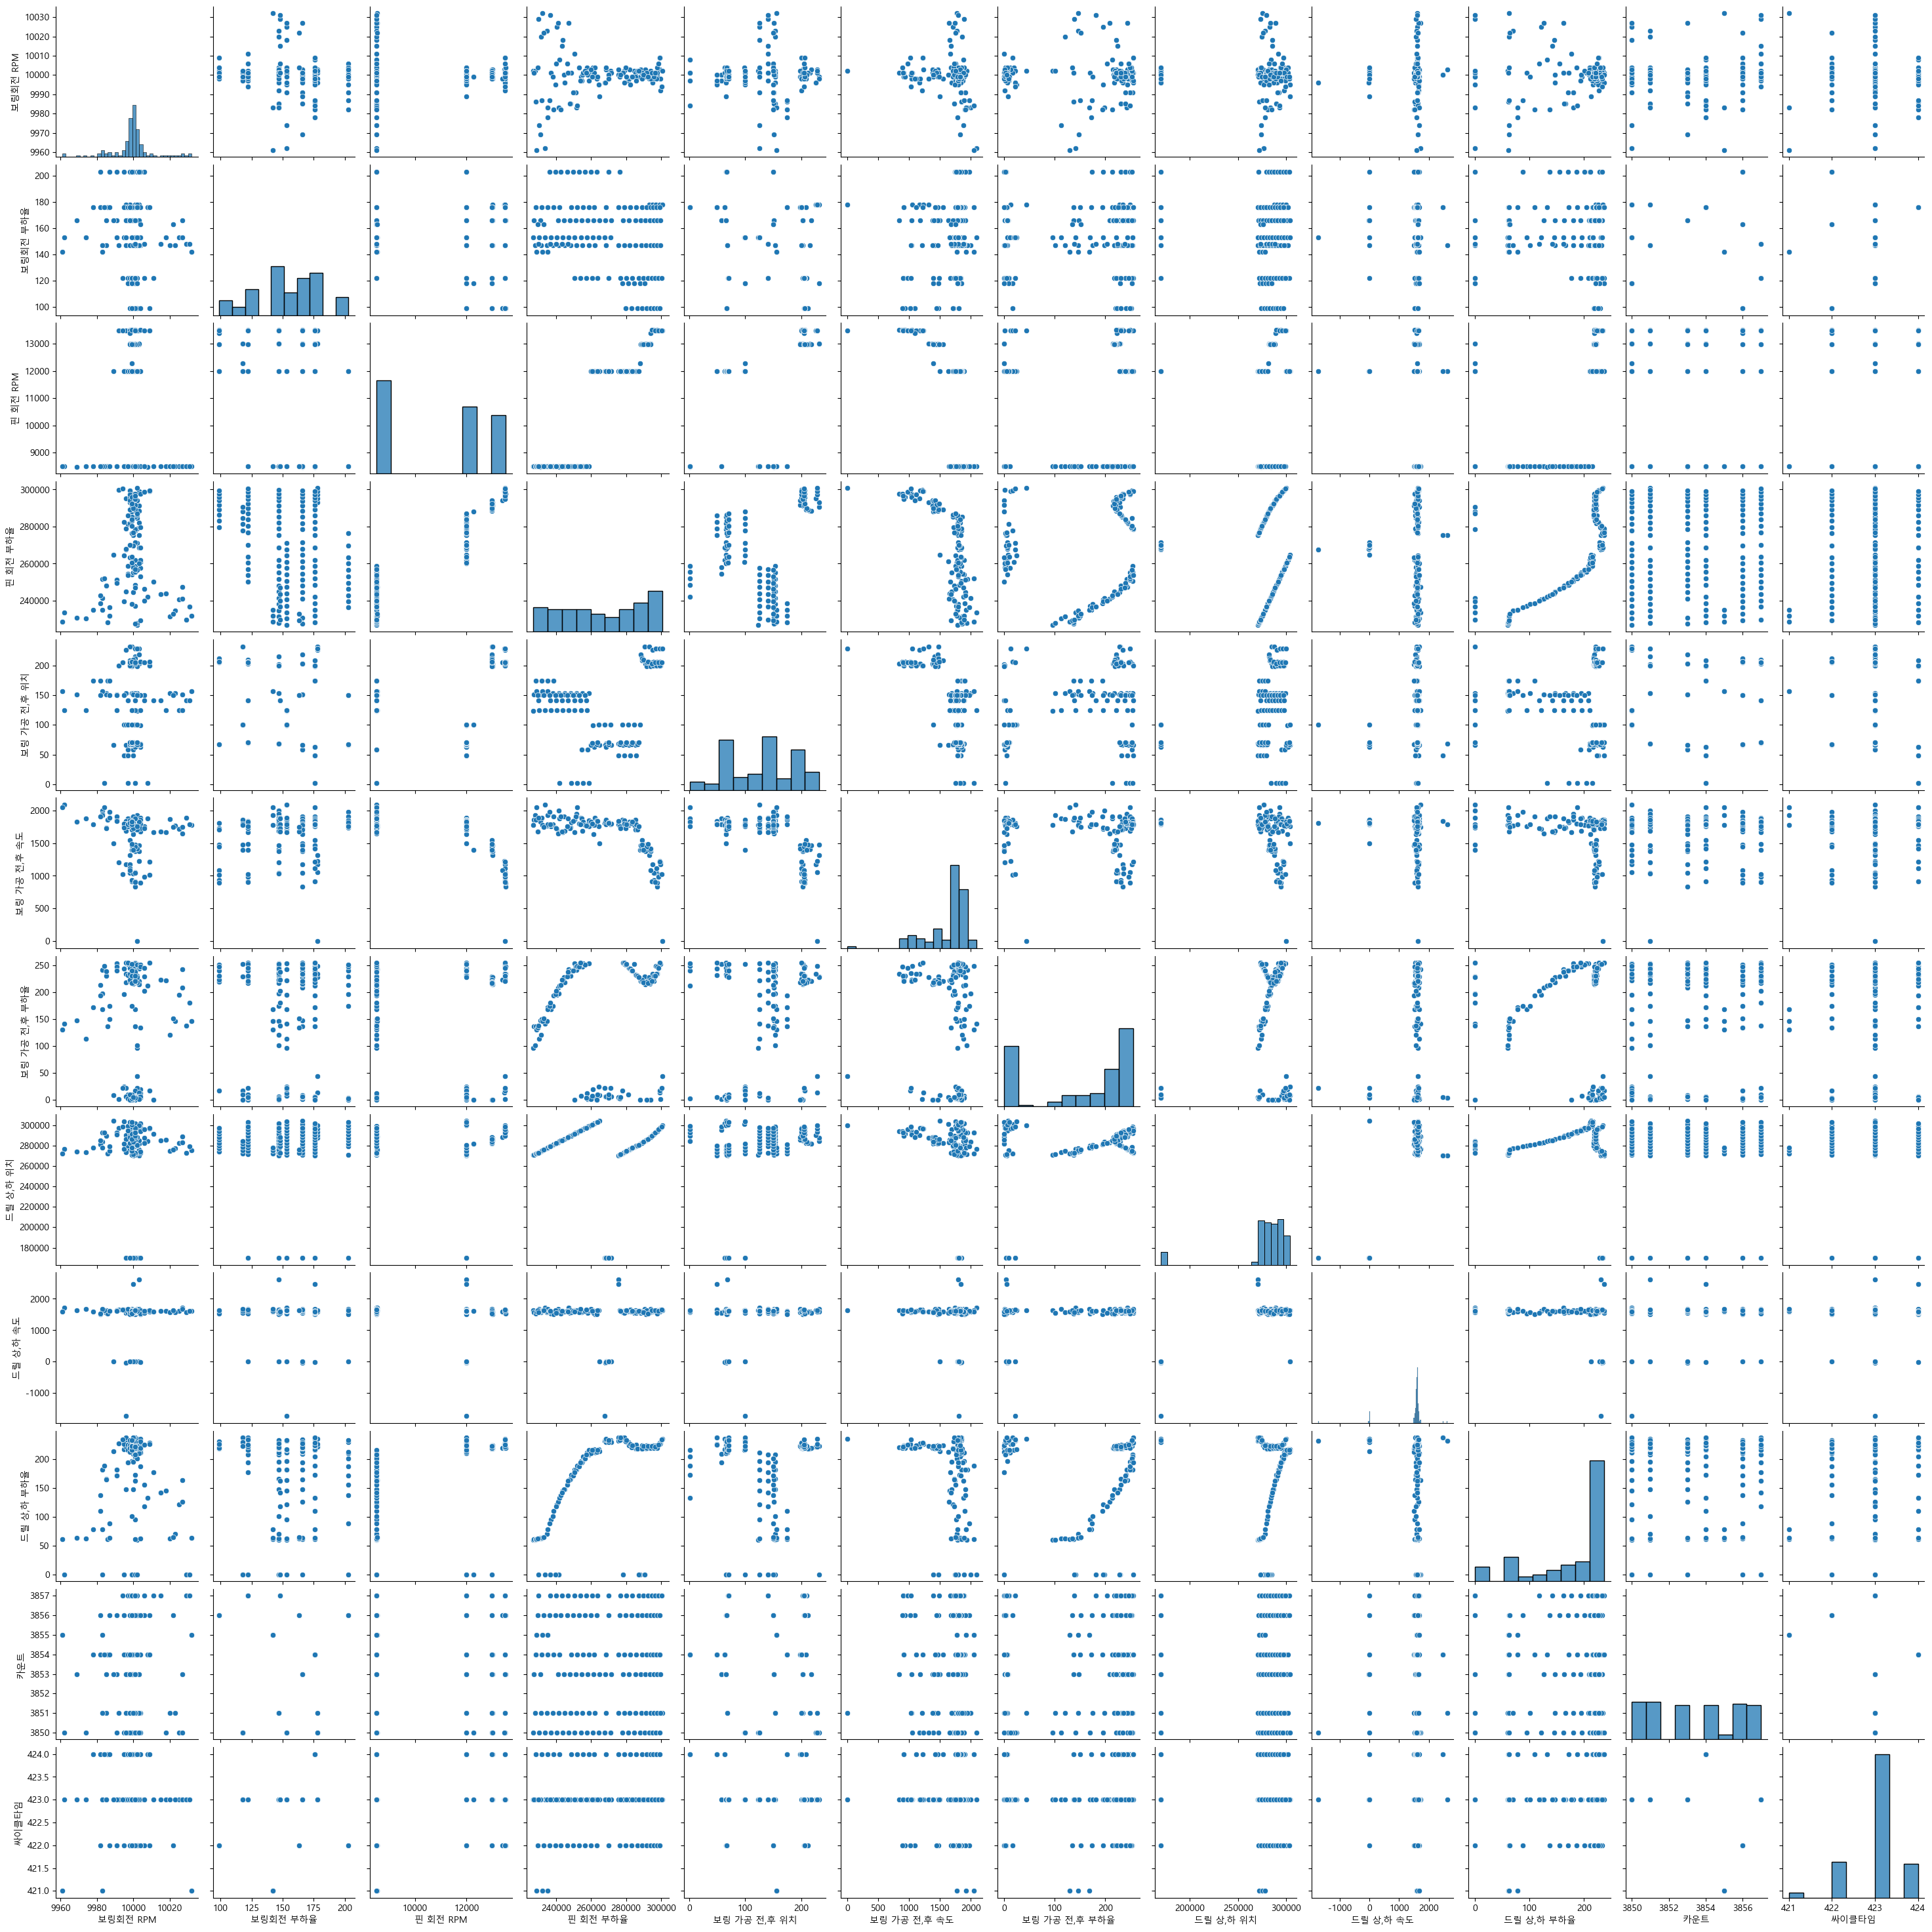

In [23]:
sns.pairplot(non_zero_data.drop(["라벨값", "등록일"], axis=1))

### OLS 회귀분석
OLS 회귀분석을 진행해보자. 다만, 변수들의 분포를 확인했을 때 한쪽으로 치우쳐진 변수들이 많았기 때문에 데이터에 로그 변환을 취한다.

In [24]:
copy_data = non_zero_data.drop("라벨값", axis=1).copy()
copy_data = log_transformation(copy_data)

로그 변환 중 4개의 결측치가 발생, 제거 완료


또한, pairplot의 결과를 봤을 때, 데이터 간 비선형적인 관계들이 보였기 때문에 다항회귀를 적용하여 분석한다.

In [25]:
# "보링회전 부하율", "핀 회전 RPM", "드릴 상,하 부하율", "카운트", "싸이클타임"
X = copy_data.drop(["보링 가공 전,후 속도", "등록일"], axis=1)
y = copy_data['보링 가공 전,후 속도']
X = sm.add_constant(X)
poly = PolynomialFeatures(degree=2, include_bias=True, order="F")
X_poly = poly.fit_transform(X)

model = sm.OLS(y, X_poly).fit()
print(model.summary()) 

                            OLS Regression Results                            
Dep. Variable:           보링 가공 전,후 속도   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     19.17
Date:                Wed, 19 Feb 2025   Prob (F-statistic):           8.95e-22
Time:                        15:22:49   Log-Likelihood:                 236.55
No. Observations:                 130   AIC:                            -317.1
Df Residuals:                      52   BIC:                            -93.43
Df Model:                          77                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.073e+06    2.9e+06     -0.370      0.7

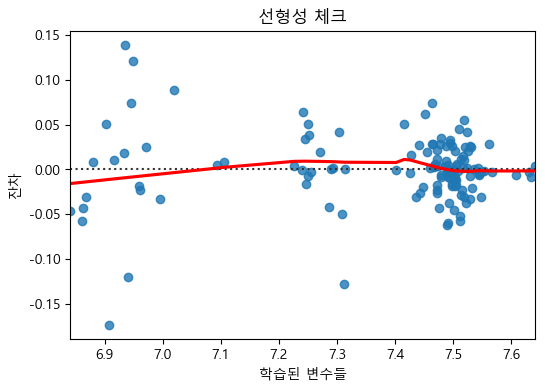

In [26]:
plt.figure(figsize=(6, 4))
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, line_kws={"color":"red"})
plt.xlabel("학습된 변수들")
plt.ylabel("잔차")
plt.title("선형성 체크")
plt.show()

### OLS 분석 결과
데이터의 경우 예측하려는 타겟에 대해 약 96%의 설명력을 가진다.

### 고려해야 할 사항
현재 PolynomialFeature를 활용해 고차항 특성들을 추가해 둔 상태이다. 변수가 증가함에 따라 다중 공선성이 발생할 가능성이 높으므로, 이를 완화하기 위해 ElasticNet 모델을 활용한다.  
ElasticNet은 L1 규제(Lasso)로 변수 선택을 수행하고, L2 규제(Ridge)로 다중 공선성을 완화하는 장점이 있다.  
모델의 성능을 극대화하기 위해 α 및 L1_ratio 등의 하이퍼파라미터를 최적화할 필요가 있다.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=2025)

In [28]:
reg_scaler = StandardScaler()

scaled_X_train = reg_scaler.fit_transform(X_train)
scaled_X_test = reg_scaler.transform(X_test)

In [30]:
import pickle

with open("../models/control/reg/scaler/reg_scaler.pkl", "wb") as r_scaler:
    pickle.dump(reg_scaler, r_scaler)

In [31]:
alpha_list = [0.0001, 0.001, 0.01, 0.1, 1, 10]
for alpha in alpha_list:
    els = ElasticNet(alpha=alpha, max_iter=10000, random_state=2025).fit(scaled_X_train, y_train)
    pred = els.predict(scaled_X_test)

    test_r2 = r2_score(y_test, pred)
    train_r2 = r2_score(y_train, els.predict(scaled_X_train))
    
    print(f"alpha : {alpha}, \ntrain adjust r2 score : {adjust_r2_score(scaled_X_train.shape[0], scaled_X_train.shape[1], train_r2)} \n\
test adjust r2 score : {adjust_r2_score(scaled_X_test.shape[0], scaled_X_test.shape[1], test_r2)}")
    print(f"rmse : {root_mean_squared_error(y_test, pred)}")

alpha : 0.0001, 
train adjust r2 score : 92.8507722775848 
test adjust r2 score : 92.76648655617878
rmse : 0.10440829886810739
alpha : 0.001, 
train adjust r2 score : 92.81022320203667 
test adjust r2 score : 92.74637869723733
rmse : 0.1088107841182905
alpha : 0.01, 
train adjust r2 score : 92.73003228002464 
test adjust r2 score : 92.72389120872198
rmse : 0.11353223639384043
alpha : 0.1, 
train adjust r2 score : 92.53201196547282 
test adjust r2 score : 92.56381041051725
rmse : 0.14269761793984634
alpha : 1, 
train adjust r2 score : 92.00961538461539 
test adjust r2 score : 92.03719479594449
rmse : 0.2120060672829841
alpha : 10, 
train adjust r2 score : 92.00961538461539 
test adjust r2 score : 92.03719479594449
rmse : 0.2120060672829841


### 모델 학습 결과
모델 학습 결과를 봤을 때, train set의 adjust r2 score와 test set의 adjust r2 score의 차이가 얼마 나지 않고, 그 수치도 92%로 높은 편이다.

과적합 없이 잘 학습된 모델이라고 판단할 수 있고, rmse도 0.09로 낮은 편이다.

In [32]:
left_hand_model = ElasticNet(alpha=0.0001, max_iter=10000, random_state=2025).fit(scaled_X_train, y_train)
pred = left_hand_model.predict(scaled_X_test)

test_r2 = r2_score(y_test, pred)
train_r2 = r2_score(y_train, left_hand_model.predict(scaled_X_train))
print(f"alpha : {0.001}, \ntrain adjust r2 score : {adjust_r2_score(scaled_X_train.shape[0], scaled_X_train.shape[1], train_r2)} \n\
test adjust r2 score : {adjust_r2_score(scaled_X_test.shape[0], scaled_X_test.shape[1], test_r2)}")
print(f"rmse : {root_mean_squared_error(y_test, pred)}")

alpha : 0.001, 
train adjust r2 score : 92.8507722775848 
test adjust r2 score : 92.76648655617878
rmse : 0.10440829886810739


In [33]:
np.expm1(pred).astype(int)

array([1720, 1233, 1247, 1828, 1216, 1689, 1875, 1836, 1237, 2183, 1806,
       2006, 1860, 1195, 1796, 1827, 1983, 1128, 1681, 1258, 1678, 1766,
       1904, 1618, 1251, 1784])

In [34]:
np.expm1(y_test.values).astype(int)

array([1644, 1174, 1398, 1910, 1117, 1856, 1833, 1945,  914, 2089, 1849,
       1792, 1784, 1056, 1819, 1663, 2002, 1480, 1711, 1463, 1707, 1747,
       1852, 1777, 1208, 1682])

In [35]:
resid = []
for pred, real in zip(np.expm1(pred).astype(int), np.expm1(y_test.values).astype(int)):
    print(f"prediction : {pred}, real value : {real}, resid: {pred - real}")
    resid.append(pred-real)
    
print(sum([np.abs(val) for val in resid]) / len(resid))

prediction : 1720, real value : 1644, resid: 76
prediction : 1233, real value : 1174, resid: 59
prediction : 1247, real value : 1398, resid: -151
prediction : 1828, real value : 1910, resid: -82
prediction : 1216, real value : 1117, resid: 99
prediction : 1689, real value : 1856, resid: -167
prediction : 1875, real value : 1833, resid: 42
prediction : 1836, real value : 1945, resid: -109
prediction : 1237, real value : 914, resid: 323
prediction : 2183, real value : 2089, resid: 94
prediction : 1806, real value : 1849, resid: -43
prediction : 2006, real value : 1792, resid: 214
prediction : 1860, real value : 1784, resid: 76
prediction : 1195, real value : 1056, resid: 139
prediction : 1796, real value : 1819, resid: -23
prediction : 1827, real value : 1663, resid: 164
prediction : 1983, real value : 2002, resid: -19
prediction : 1128, real value : 1480, resid: -352
prediction : 1681, real value : 1711, resid: -30
prediction : 1258, real value : 1463, resid: -205
prediction : 1678, rea

In [36]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(random_state=2025, iterations=10000, learning_rate=0.001)
cat.fit(scaled_X_train, y_train)

0:	learn: 0.2126244	total: 120ms	remaining: 20m 4s
1:	learn: 0.2125056	total: 131ms	remaining: 10m 56s
2:	learn: 0.2123728	total: 136ms	remaining: 7m 32s
3:	learn: 0.2122498	total: 141ms	remaining: 5m 52s
4:	learn: 0.2121123	total: 142ms	remaining: 4m 44s
5:	learn: 0.2119852	total: 145ms	remaining: 4m 1s
6:	learn: 0.2118554	total: 148ms	remaining: 3m 30s
7:	learn: 0.2117269	total: 150ms	remaining: 3m 7s
8:	learn: 0.2115916	total: 152ms	remaining: 2m 48s
9:	learn: 0.2114462	total: 154ms	remaining: 2m 34s
10:	learn: 0.2113164	total: 156ms	remaining: 2m 22s
11:	learn: 0.2111819	total: 158ms	remaining: 2m 11s
12:	learn: 0.2110549	total: 160ms	remaining: 2m 2s
13:	learn: 0.2109341	total: 161ms	remaining: 1m 54s
14:	learn: 0.2107996	total: 163ms	remaining: 1m 48s
15:	learn: 0.2106747	total: 164ms	remaining: 1m 42s
16:	learn: 0.2105362	total: 166ms	remaining: 1m 37s
17:	learn: 0.2103934	total: 167ms	remaining: 1m 32s
18:	learn: 0.2102816	total: 168ms	remaining: 1m 28s
19:	learn: 0.2101516	tot

In [37]:
from joblib import dump

dump(cat, "../models/control/reg/model/reg_model.V1.0.joblib")

['../models/control/reg/model/reg_model.V1.0.joblib']

In [38]:
pred = cat.predict(scaled_X_test)

test_r2 = r2_score(y_test, pred)
train_r2 = r2_score(y_train, cat.predict(scaled_X_train))

print(f"train adjust r2 score : {adjust_r2_score(scaled_X_train.shape[0], scaled_X_train.shape[1], train_r2)} \n\
test adjust r2 score : {adjust_r2_score(scaled_X_test.shape[0], scaled_X_test.shape[1], test_r2)}")
print(f"rmse : {root_mean_squared_error(y_test, pred)}")

train adjust r2 score : 92.99440047972888 
test adjust r2 score : 92.89108417772825
rmse : 0.07130575172916881


In [39]:
np.expm1(pred).astype(int)

array([1760, 1147, 1358, 1764, 1134, 1769, 1753, 1827, 1149, 1829, 1797,
       1741, 1883, 1160, 1777, 1759, 1791, 1448, 1775, 1428, 1761, 1771,
       1808, 1815, 1224, 1831])

In [40]:
np.expm1(y_test.values).astype(int)

array([1644, 1174, 1398, 1910, 1117, 1856, 1833, 1945,  914, 2089, 1849,
       1792, 1784, 1056, 1819, 1663, 2002, 1480, 1711, 1463, 1707, 1747,
       1852, 1777, 1208, 1682])

In [41]:
resid = []
for pred, real in zip(np.expm1(pred).astype(int), np.expm1(y_test.values).astype(int)):
    print(f"prediction : {pred}, real value : {real}, resid: {pred - real}")
    resid.append(pred-real)

prediction : 1760, real value : 1644, resid: 116
prediction : 1147, real value : 1174, resid: -27
prediction : 1358, real value : 1398, resid: -40
prediction : 1764, real value : 1910, resid: -146
prediction : 1134, real value : 1117, resid: 17
prediction : 1769, real value : 1856, resid: -87
prediction : 1753, real value : 1833, resid: -80
prediction : 1827, real value : 1945, resid: -118
prediction : 1149, real value : 914, resid: 235
prediction : 1829, real value : 2089, resid: -260
prediction : 1797, real value : 1849, resid: -52
prediction : 1741, real value : 1792, resid: -51
prediction : 1883, real value : 1784, resid: 99
prediction : 1160, real value : 1056, resid: 104
prediction : 1777, real value : 1819, resid: -42
prediction : 1759, real value : 1663, resid: 96
prediction : 1791, real value : 2002, resid: -211
prediction : 1448, real value : 1480, resid: -32
prediction : 1775, real value : 1711, resid: 64
prediction : 1428, real value : 1463, resid: -35
prediction : 1761, re

In [42]:
print(sum([np.abs(val) for val in resid]) / len(resid))

86.03846153846153
